In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier


In [4]:
df = pd.read_csv("../Data/Train.csv")
print("Dataset Shape:", df.shape)
df.head()
print("Missing Values\n")
print(df.isnull().sum())

Dataset Shape: (1000, 12)
Missing Values

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [5]:
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
y_pred = xgb_model.predict(X_test)
print("First Predictions:", y_pred[:10])

First Predictions: [1 1 1 1 1 0 1 0 1 1]


In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.535


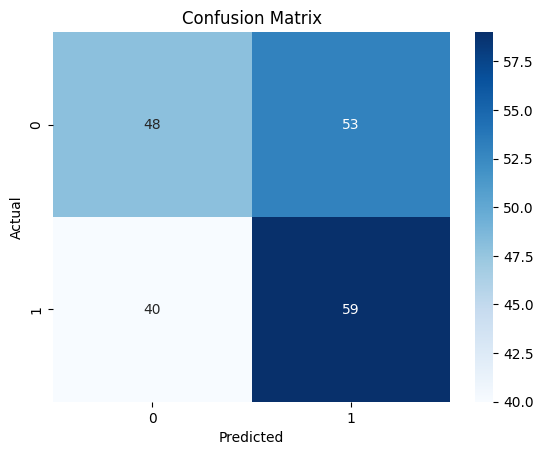

In [8]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [12]:
import pickle
import os
os.makedirs("models", exist_ok=True)
# save trained model 
with open("models/1model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
print("Model saved successfully")

Model saved successfully


In [13]:
with open("models/1model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
test_pred = loaded_model.predict(X_test[:5])
print("Loaded model predictions:", test_pred)

Loaded model predictions: [1 1 1 1 1]
